In [26]:
from IPython.core.interactiveshell import io
!git clone https://github.com/ahsan-nafees/.github.io.git
%cd .github.io

Cloning into '.github.io'...
remote: Enumerating objects: 3118, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 3118 (delta 3), reused 1 (delta 1), pack-reused 3111 (from 1)
Receiving objects: 100% (3118/3118), 46.71 MiB | 23.12 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/.github.io/.github.io/.github.io


In [27]:
!pip install mahotas opencv-python h5py scikit-learn matplotlib seaborn joblib pandas numpy

In [28]:
import os

os.makedirs("dataset/train", exist_ok=True)
os.makedirs("dataset/test", exist_ok=True)
os.makedirs("embeddings/features", exist_ok=True)
os.makedirs("embeddings/labels", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [29]:
from google.colab import files

uploaded = files.upload()

Saving disease-detection-for-apple-leaves-master.zip to disease-detection-for-apple-leaves-master.zip


In [30]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset/train")

print("Dataset extracted.")
print(os.listdir("dataset/train"))

Dataset extracted.
['disease-detection-for-apple-leaves-master']


In [35]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
import mahotas
import cv2
import os
import h5py

images_per_class = 800
fixed_size = (500, 500)
# Corrected train_path to point to the actual image directories
train_path = "dataset/train/disease-detection-for-apple-leaves-master/images"
h5_train_features = "embeddings/features/features.h5"
h5_train_labels = "embeddings/labels/labels.h5"
bins = 8

def rgb_bgr(image):
    rgb_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return rgb_img

def bgr_hsv(rgb_img):
    hsv_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)
    return hsv_img

def img_segmentation(rgb_img, hsv_img):
    lower_green = np.array([25, 0, 20])
    upper_green = np.array([100, 255, 255])
    healthy_mask = cv2.inRange(hsv_img, lower_green, upper_green)

    lower_brown = np.array([10, 0, 10])
    upper_brown = np.array([30, 255, 255])
    disease_mask = cv2.inRange(hsv_img, lower_brown, upper_brown)

    final_mask = healthy_mask + disease_mask
    final_result = cv2.bitwise_and(rgb_img, rgb_img, mask=final_mask)

    return final_result

def fd_hu_moments(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    feature = cv2.HuMoments(cv2.moments(image)).flatten()
    return feature

def fd_haralick(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    return haralick

def fd_histogram(image, mask=None):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [image],
        [0, 1, 2],
        None,
        [bins, bins, bins],
        [0, 256, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist)
    return hist.flatten()

train_labels = os.listdir(train_path)
train_labels.sort()

print("Detected classes:", train_labels)

global_features = []
labels = []

for training_name in train_labels:
    img_dir_path = os.path.join(train_path, training_name)
    current_label = training_name

    if not os.path.isdir(img_dir_path):
        continue

    count = 0

    for img in os.listdir(img_dir_path):
        file = os.path.join(img_dir_path, img)

        image = cv2.imread(file)

        if image is None:
            continue

        image = cv2.resize(image, fixed_size)

        RGB_BGR = rgb_bgr(image)
        BGR_HSV = bgr_hsv(RGB_BGR)
        IMG_SEGMENT = img_segmentation(RGB_BGR, BGR_HSV)

        fv_hu_moments = fd_hu_moments(IMG_SEGMENT)
        fv_haralick = fd_haralick(IMG_SEGMENT)
        fv_histogram = fd_histogram(IMG_SEGMENT)

        global_feature = np.hstack([
            fv_histogram,
            fv_haralick,
            fv_hu_moments
        ])

        labels.append(current_label)
        global_features.append(global_feature)

        count += 1

    print(f"[STATUS] processed folder: {current_label}, images: {count}")

print("[STATUS] completed Global Feature Extraction")
print("[STATUS] feature vector size:", np.array(global_features).shape)
print("[STATUS] labels size:", np.array(labels).shape)

targetNames = np.unique(labels)
le = LabelEncoder()
target = le.fit_transform(labels)

scaler = MinMaxScaler(feature_range=(0, 1))
rescaled_features = scaler.fit_transform(global_features)

h5f_data = h5py.File(h5_train_features, "w")
h5f_data.create_dataset("dataset_1", data=np.array(rescaled_features))
h5f_data.close()

h5f_label = h5py.File(h5_train_labels, "w")
h5f_label.create_dataset("dataset_1", data=np.array(target))
h5f_label.close()

print("[STATUS] Features and labels saved successfully.")
print("Classes:", targetNames)


Detected classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
[STATUS] processed folder: Apple___Apple_scab, images: 630
[STATUS] processed folder: Apple___Black_rot, images: 621
[STATUS] processed folder: Apple___Cedar_apple_rust, images: 275
[STATUS] processed folder: Apple___healthy, images: 1645
[STATUS] completed Global Feature Extraction
[STATUS] feature vector size: (3171, 532)
[STATUS] labels size: (3171,)
[STATUS] Features and labels saved successfully.
Classes: ['Apple___Apple_scab' 'Apple___Black_rot' 'Apple___Cedar_apple_rust'
 'Apple___healthy']


In [36]:
import h5py
import numpy as np
import warnings
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

num_trees = 100
test_size = 0.2
seed = 9
scoring = "accuracy"

h5_train_features = "embeddings/features/features.h5"
h5_train_labels = "embeddings/labels/labels.h5"

h5f_data = h5py.File(h5_train_features, "r")
h5f_label = h5py.File(h5_train_labels, "r")

global_features = np.array(h5f_data["dataset_1"])
global_labels = np.array(h5f_label["dataset_1"])

h5f_data.close()
h5f_label.close()

print("[STATUS] features shape:", global_features.shape)
print("[STATUS] labels shape:", global_labels.shape)

trainDataGlobal, testDataGlobal, trainLabelsGlobal, testLabelsGlobal = train_test_split(
    global_features,
    global_labels,
    test_size=test_size,
    random_state=seed,
    stratify=global_labels
)

models = []
models.append(("LR", LogisticRegression(random_state=seed, max_iter=1000)))
models.append(("LDA", LinearDiscriminantAnalysis()))
models.append(("KNN", KNeighborsClassifier()))
models.append(("DTC", DecisionTreeClassifier(random_state=seed)))
models.append(("RF", RandomForestClassifier(n_estimators=num_trees, random_state=seed)))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC(random_state=seed)))

results = []
names = []

print("[STATUS] Model training and cross-validation started...\n")

for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = cross_val_score(
        model,
        trainDataGlobal,
        trainLabelsGlobal,
        cv=kfold,
        scoring=scoring
    )
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.6f} ({cv_results.std():.6f})")

[STATUS] features shape: (3171, 532)
[STATUS] labels shape: (3171,)
[STATUS] Model training and cross-validation started...

LR: 0.901830 (0.018627)
LDA: 0.893531 (0.012995)
KNN: 0.903405 (0.014575)
DTC: 0.892353 (0.013186)
RF: 0.966476 (0.014573)
NB: 0.833992 (0.013794)
SVM: 0.890378 (0.017109)


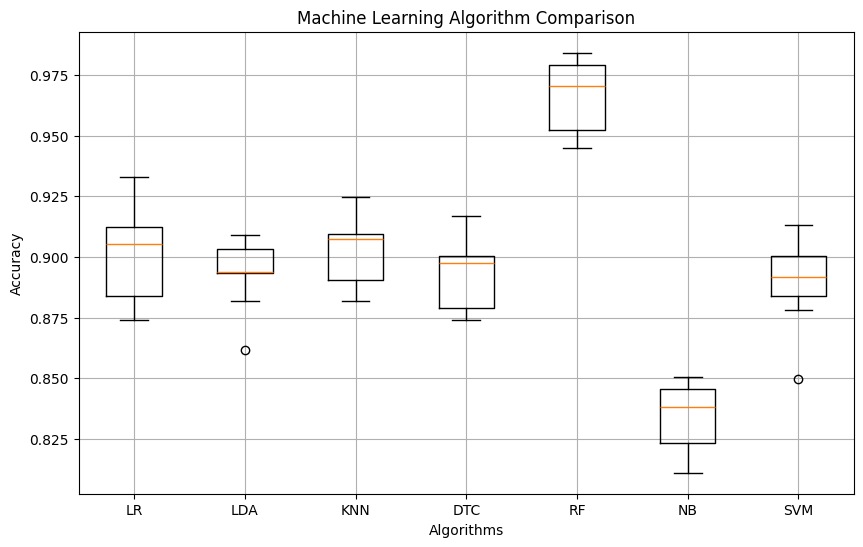

In [37]:
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names)
plt.title("Machine Learning Algorithm Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [38]:
clf = RandomForestClassifier(n_estimators=100, random_state=9)
clf.fit(trainDataGlobal, trainLabelsGlobal)

y_predict = clf.predict(testDataGlobal)

accuracy = accuracy_score(testLabelsGlobal, y_predict)

print("Random Forest Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(testLabelsGlobal, y_predict))

Random Forest Accuracy: 0.9669291338582677

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       126
           1       0.98      1.00      0.99       124
           2       1.00      0.96      0.98        55
           3       0.98      0.97      0.97       330

    accuracy                           0.97       635
   macro avg       0.97      0.96      0.97       635
weighted avg       0.97      0.97      0.97       635



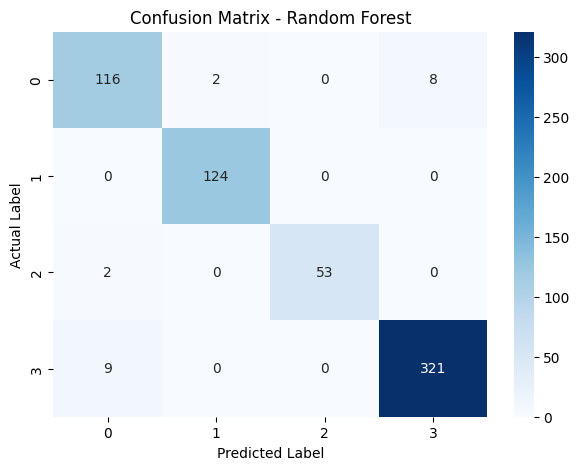

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(testLabelsGlobal, y_predict)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [41]:
import joblib

joblib.dump(clf, "models/random_forest_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")

print("Model, scaler, and label encoder saved successfully.")

Model, scaler, and label encoder saved successfully.


In [42]:
from google.colab import files
import cv2
import numpy as np
import joblib
import mahotas

uploaded_test = files.upload()

test_img_name = list(uploaded_test.keys())[0]

image = cv2.imread(test_img_name)
image = cv2.resize(image, (500, 500))

RGB_BGR = rgb_bgr(image)
BGR_HSV = bgr_hsv(RGB_BGR)
IMG_SEGMENT = img_segmentation(RGB_BGR, BGR_HSV)

fv_hu_moments = fd_hu_moments(IMG_SEGMENT)
fv_haralick = fd_haralick(IMG_SEGMENT)
fv_histogram = fd_histogram(IMG_SEGMENT)

global_feature = np.hstack([
    fv_histogram,
    fv_haralick,
    fv_hu_moments
])

global_feature = global_feature.reshape(1, -1)
global_feature = scaler.transform(global_feature)

prediction = clf.predict(global_feature)
predicted_class = le.inverse_transform(prediction)

print("Predicted Disease Class:", predicted_class[0])

Saving PLPATH-FRU-07-Black-Rot-Frogeye-Apple-figure-2.png to PLPATH-FRU-07-Black-Rot-Frogeye-Apple-figure-2.png
Predicted Disease Class: Apple___Black_rot
